In [1]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt


In [2]:
database = "database.sqlite2\database.sqlite"
conn = sqlite3.connect(database)

<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\hp\AppData\Local\Temp\ipykernel_6452\2674716883.py:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  database = "database.sqlite2\database.sqlite"


In [4]:
tables = pd.read_sql("""SELECT *
                         FROM sqlite_master 
                        WHERE type='table';""", conn)
tables

,type,name,tbl_name,rootpage,sql
0,table,Country,Country,2,"CREATE TABLE Country (\n CountryCode TEXT,\..."
1,table,CountryNotes,CountryNotes,186,CREATE TABLE CountryNotes (\n Countrycode T...
2,table,Series,Series,948,"CREATE TABLE Series (\n SeriesCode TEXT,\n ..."
3,table,Indicators,Indicators,4448,CREATE TABLE Indicators (\n CountryName TEX...
4,table,SeriesNotes,SeriesNotes,1317550,CREATE TABLE SeriesNotes (\n Seriescode TEX...
5,table,Footnotes,Footnotes,1317587,CREATE TABLE Footnotes (\n Countrycode TEXT...


In [ ]:
indicators_table = pd.read_sql("""SELECT *
                            FROM Indicators
                            where countryname in(select distinct countryname from Country 
                            where region="Middle East & North Africa");""", conn)
indicators_table

In [8]:
count_of_countries = pd.read_sql("""SELECT  distinct CountryName 
                            FROM Indicators
                            where Countrycode="ARB";""", conn)
count_of_countries

,CountryName
0,Arab World


In [14]:
country_table = pd.read_sql("""SELECT   *
                            FROM Country
                            where region="Middle East & North Africa";""", conn)
country_table

,CountryCode,ShortName,TableName,LongName,Alpha2Code,CurrencyUnit,SpecialNotes,Region,IncomeGroup,Wb2Code,...,GovernmentAccountingConcept,ImfDataDisseminationStandard,LatestPopulationCensus,LatestHouseholdSurvey,SourceOfMostRecentIncomeAndExpenditureData,VitalRegistrationComplete,LatestAgriculturalCensus,LatestIndustrialData,LatestTradeData,LatestWaterWithdrawalData
0,DZA,Algeria,Algeria,People's Democratic Republic of Algeria,DZ,Algerian dinar,,Middle East & North Africa,Upper middle income,DZ,...,Budgetary central government,General Data Dissemination System (GDDS),2008,"Multiple Indicator Cluster Survey (MICS), 2012","Integrated household survey (IHS), 1995",,,2010,2013,2001
1,BHR,Bahrain,Bahrain,Kingdom of Bahrain,BH,Bahraini dinar,Based on official government statistics; the n...,Middle East & North Africa,High income: nonOECD,BH,...,Budgetary central government,General Data Dissemination System (GDDS),2010,,,Yes,,2010,2011,2003
2,DJI,Djibouti,Djibouti,Republic of Djibouti,DJ,Djibouti franc,,Middle East & North Africa,Lower middle income,DJ,...,,General Data Dissemination System (GDDS),2009,"Multiple Indicator Cluster Survey (MICS), 2006","Priority survey (PS), 2002",,,,2009,2000
3,EGY,Egypt,"Egypt, Arab Rep.",Arab Republic of Egypt,EG,Egyptian pound,Fiscal year end: June 30; reporting period for...,Middle East & North Africa,Lower middle income,EG,...,Consolidated central government,Special Data Dissemination Standard (SDDS),2006,"Demographic and Health Survey (DHS), 2014","Expenditure survey/budget survey (ES/BS), 2011",Yes,2009/2010,2010,2013,2000
4,IRN,Iran,"Iran, Islamic Rep.",Islamic Republic of Iran,IR,Iranian rial,Fiscal year end: March 20; reporting period fo...,Middle East & North Africa,Upper middle income,IR,...,Consolidated central government,General Data Dissemination System (GDDS),2011,Iran's Multiple Indicator Demographic and Heal...,"Expenditure survey/budget survey (ES/BS), 2005",Yes,2013,2010,2011,2004
5,IRQ,Iraq,Iraq,Republic of Iraq,IQ,Iraqi dinar,,Middle East & North Africa,Upper middle income,IQ,...,,General Data Dissemination System (GDDS),1997,"Multiple Indicator Cluster Survey (MICS), 2011","Integrated household survey (IHS), 2012",,2011/2012,2011,,2000
6,ISR,Israel,Israel,State of Israel,IL,Israeli new shekel,Based on official government statistics for ch...,Middle East & North Africa,High income: OECD,IL,...,Consolidated central government,Special Data Dissemination Standard (SDDS),2009,,"Expenditure survey/budget survey (ES/BS), 2010",Yes,,2010,2013,2004
7,JOR,Jordan,Jordan,Hashemite Kingdom of Jordan,JO,Jordanian dinar,,Middle East & North Africa,Upper middle income,JO,...,,Special Data Dissemination Standard (SDDS),2004,"Demographic and Health Survey (DHS), 2012","Expenditure survey/budget survey (ES/BS), 2010",,2007,2011,2013,2005
8,KWT,Kuwait,Kuwait,State of Kuwait,KW,Kuwaiti dinar,Fiscal year end: June 30; reporting period for...,Middle East & North Africa,High income: nonOECD,KW,...,Budgetary central government,General Data Dissemination System (GDDS),2011,"Family Health Survey (FHS), 1996",,Yes,,2011,2013,2002
9,LBN,Lebanon,Lebanon,Lebanese Republic,LB,Lebanese pound,,Middle East & North Africa,Upper middle income,LB,...,Budgetary central government,General Data Dissemination System (GDDS),1943,"Family Health Survey (FHS), 2004",,Yes,2011,2007,2013,2005


In [25]:
tables = ['Country', 'Indicators', 'Series', 'CountryNotes', 'SeriesNotes', 'Footnotes']
for t in tables:
    df = pd.read_sql(f"SELECT * FROM {t}", conn)
    df.to_csv(f"{t}.csv", index=False)

In [43]:
life_expectancy_countries = pd.read_sql("""
    SELECT  *
    FROM Indicators
    where CountryName in ('Egypt, Arab Rep.', 'Saudi Arabia','United Arab Emirates','Morocco'  ,'Yemen, Rep.' ,'Tunisia','West Bank and Gaza','Iran, Islamic Rep.','Iraq'
                           ,'Syria','Libya' )
    and indicatorname  = 'Life expectancy at birth, total (years)'
    
""", conn)
life_expectancy_countries

,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
0,"Egypt, Arab Rep.",EGY,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1960,48.013707
1,"Iran, Islamic Rep.",IRN,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1960,44.945512
2,Iraq,IRQ,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1960,48.030683
3,Libya,LBY,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1960,42.641195
4,Morocco,MAR,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1960,48.446634
...,...,...,...,...,...,...
505,Saudi Arabia,SAU,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2013,74.177634
506,Tunisia,TUN,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2013,73.646341
507,United Arab Emirates,ARE,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2013,77.195634
508,West Bank and Gaza,WBG,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2013,73.203341


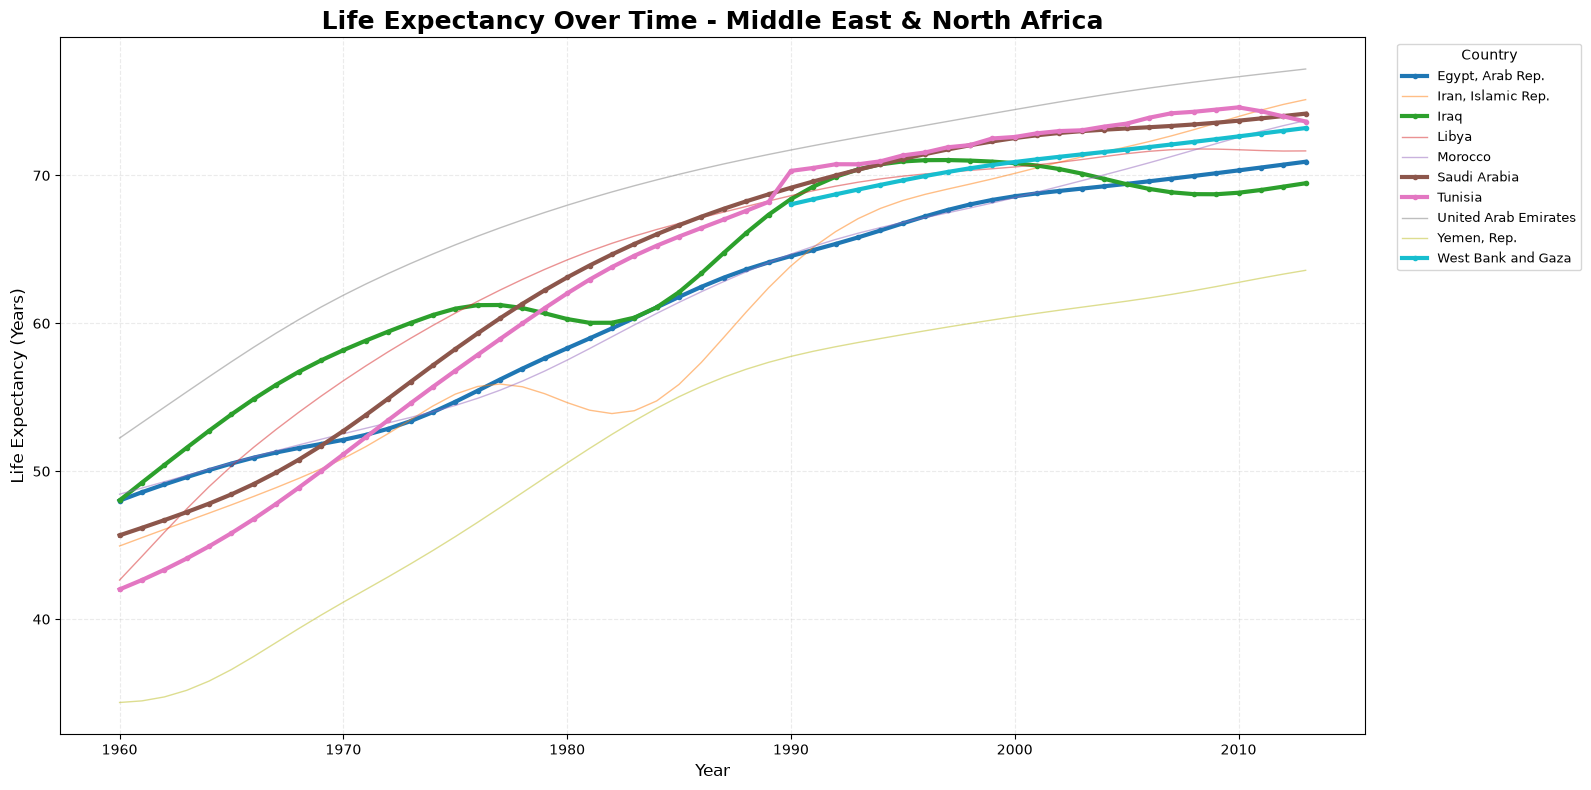

In [44]:
plt.figure(figsize=(16, 8))

highlighted = ['Egypt, Arab Rep.', 'West Bank and Gaza', 'Iraq','Saudi Arabia','Tunisia']

for country in life_expectancy_countries['CountryName'].unique():
    country_data = life_expectancy_countries[
        life_expectancy_countries['CountryName'] == country
    ]

    if country in highlighted:
        plt.plot(
            country_data['Year'],
            country_data['Value'],
            label=country,
            linewidth=3,
            marker='o',
            markersize=3
        )
    else:
        plt.plot(
            country_data['Year'],
            country_data['Value'],
            label=country,
            linewidth=1,
            alpha=0.5
        )

plt.title(
    'Life Expectancy Over Time - Middle East & North Africa',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Life Expectancy (Years)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.25)

plt.legend(
    title='Country',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=9
)

plt.tight_layout()
plt.show()

In [49]:
lifetime_risk_of_maternal_death = pd.read_sql("""
    SELECT   *
    FROM Indicators
    where CountryName in ('Egypt, Arab Rep.', 'West Bank and Gaza', 'Iraq','Saudi Arabia','Tunisia' )
    and indicatorname   ='Lifetime risk of maternal death (%)'
    
""", conn)
lifetime_risk_of_maternal_death

,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
0,"Egypt, Arab Rep.",EGY,Lifetime risk of maternal death (%),SH.MMR.RISK.ZS,1990,0.533855
1,Iraq,IRQ,Lifetime risk of maternal death (%),SH.MMR.RISK.ZS,1990,0.633937
2,Saudi Arabia,SAU,Lifetime risk of maternal death (%),SH.MMR.RISK.ZS,1990,0.288589
3,Tunisia,TUN,Lifetime risk of maternal death (%),SH.MMR.RISK.ZS,1990,0.485753
4,West Bank and Gaza,WBG,Lifetime risk of maternal death (%),SH.MMR.RISK.ZS,1990,0.864006
...,...,...,...,...,...,...
125,"Egypt, Arab Rep.",EGY,Lifetime risk of maternal death (%),SH.MMR.RISK.ZS,2015,0.122989
126,Iraq,IRQ,Lifetime risk of maternal death (%),SH.MMR.RISK.ZS,2015,0.240565
127,Saudi Arabia,SAU,Lifetime risk of maternal death (%),SH.MMR.RISK.ZS,2015,0.032569
128,Tunisia,TUN,Lifetime risk of maternal death (%),SH.MMR.RISK.ZS,2015,0.140912


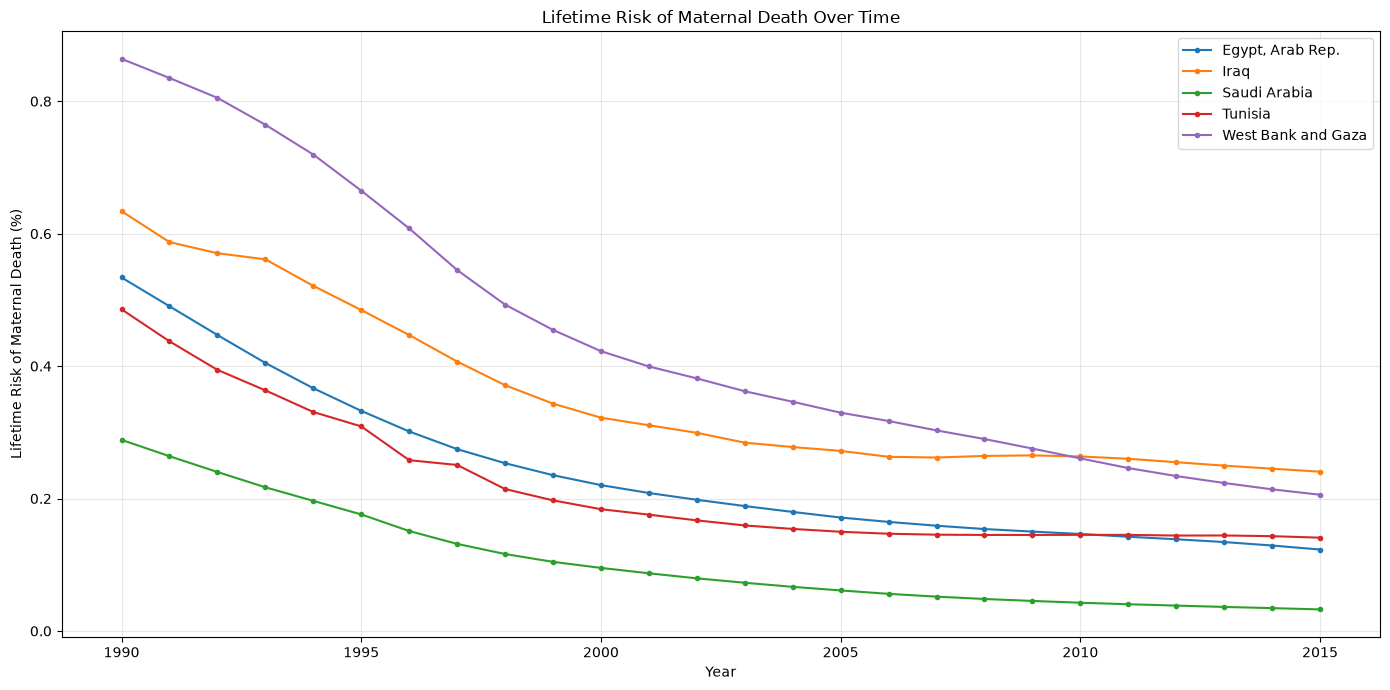

In [51]:
plt.figure(figsize=(14, 7))

for country in lifetime_risk_of_maternal_death['CountryName'].unique():
    country_data = lifetime_risk_of_maternal_death[
        lifetime_risk_of_maternal_death['CountryName'] == country
    ]
    
    plt.plot(
        country_data['Year'],
        country_data['Value'],
        label=country,
        marker='o',
        markersize=3
    )

plt.title('Lifetime Risk of Maternal Death Over Time')
plt.xlabel('Year')
plt.ylabel('Lifetime Risk of Maternal Death (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [66]:
literacy_rate_countries = pd.read_sql("""
    SELECT  distinct indicatorname
    FROM Indicators
    where CountryName in ('Egypt, Arab Rep.' )
    and indicatorname   like 'Government expenditure on education%'
    limit 60
""", conn)
literacy_rate_countries

,IndicatorName
0,Government expenditure on education as % of GD...


In [64]:
education = pd.read_sql("""
    SELECT CountryName, Year, Value
    FROM Indicators
    WHERE CountryName IN (
        'Egypt, Arab Rep.',
        'West Bank and Gaza',
        'Iraq',
        'Saudi Arabia',
        'Tunisia'
    )
    AND IndicatorName  like 'Government expenditure on education%'
    limit 40
    
""", conn)

education 

,CountryName,Year,Value
0,"Egypt, Arab Rep.",1971,4.74202
1,"Egypt, Arab Rep.",1972,4.72636
2,"Egypt, Arab Rep.",1974,5.48853
3,"Egypt, Arab Rep.",1975,5.00846
4,"Egypt, Arab Rep.",1976,5.02737
5,"Egypt, Arab Rep.",1977,4.53443
6,"Egypt, Arab Rep.",1978,4.86171
7,"Egypt, Arab Rep.",1980,4.24980
8,"Egypt, Arab Rep.",1982,5.30415
9,"Egypt, Arab Rep.",1983,5.64235


In [6]:
education_expenditure = pd.read_sql("""
SELECT CountryName, Year, Value
FROM Indicators
WHERE CountryName IN (
    'Egypt, Arab Rep.',
    'West Bank and Gaza',
    'Iraq',
    'Saudi Arabia',
    'Tunisia'
)
AND IndicatorName LIKE 'Government expenditure on education%'
AND Value IS NOT NULL
ORDER BY CountryName, Year
""", conn)
education_expenditure

,CountryName,Year,Value
0,"Egypt, Arab Rep.",1971,4.74202
1,"Egypt, Arab Rep.",1972,4.72636
2,"Egypt, Arab Rep.",1974,5.48853
3,"Egypt, Arab Rep.",1975,5.00846
4,"Egypt, Arab Rep.",1976,5.02737
...,...,...,...
71,Tunisia,2007,6.46552
72,Tunisia,2008,6.27219
73,Tunisia,2009,6.52848
74,Tunisia,2010,6.20200


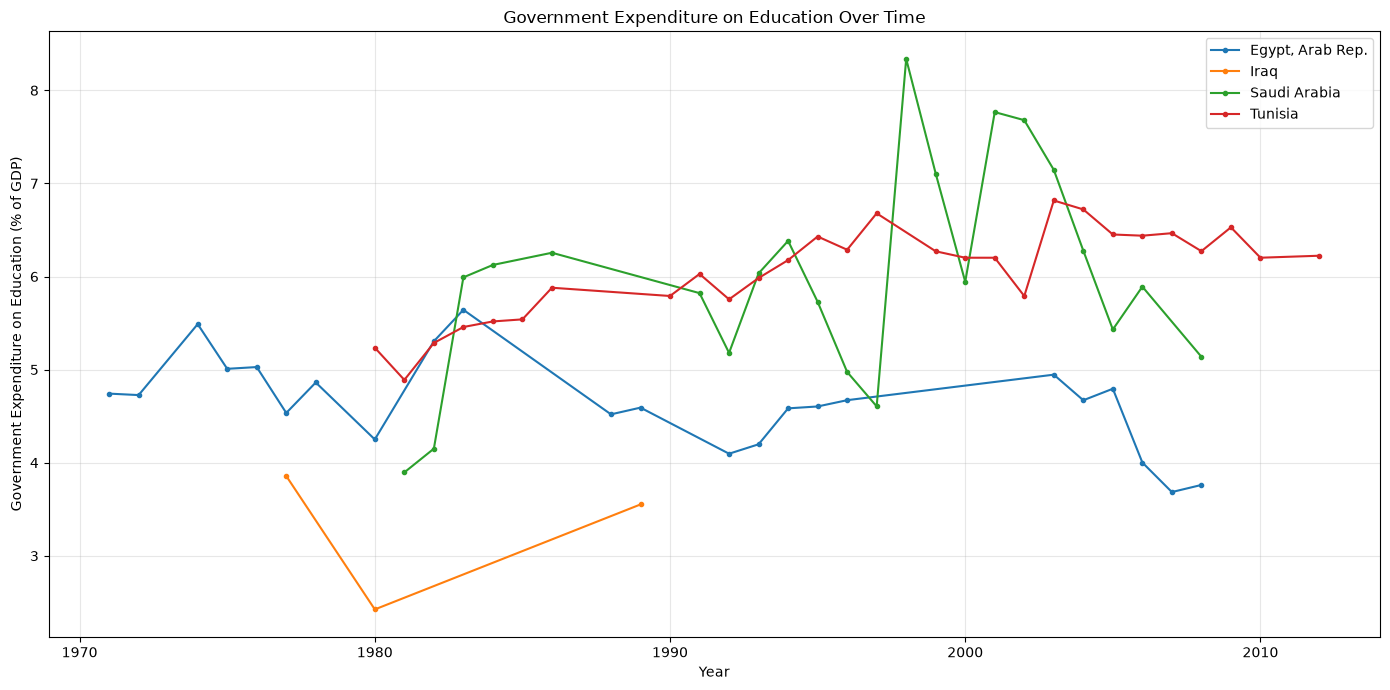

In [15]:
plt.figure(figsize=(14, 7))

for country in education_expenditure['CountryName'].unique():
    country_data = education_expenditure[
        education_expenditure['CountryName'] == country
    ]

    plt.plot(
        country_data['Year'],
        country_data['Value'],
        label=country,
        marker='o',
        markersize=3
    )

plt.title('Government Expenditure on Education Over Time')
plt.xlabel('Year')
plt.ylabel('Government Expenditure on Education (% of GDP)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [3]:
secondary_students = pd.read_sql("""
SELECT CountryName, Year, Value
FROM Indicators
WHERE CountryName IN (
    'Egypt, Arab Rep.',
    'West Bank and Gaza',
    'Iraq',
    'Saudi Arabia',
    'Tunisia'
)
AND IndicatorName LIKE 'Percentage of students in secondary education%'
AND Value IS NOT NULL
ORDER BY CountryName, Year
""", conn)

secondary_students

,CountryName,Year,Value
0,"Egypt, Arab Rep.",1971,32.170110
1,"Egypt, Arab Rep.",1972,32.695910
2,"Egypt, Arab Rep.",1973,33.146630
3,"Egypt, Arab Rep.",1974,33.625920
4,"Egypt, Arab Rep.",1975,33.196390
...,...,...,...
119,West Bank and Gaza,2009,50.631512
120,West Bank and Gaza,2010,50.890381
121,West Bank and Gaza,2011,51.420078
122,West Bank and Gaza,2012,51.255741


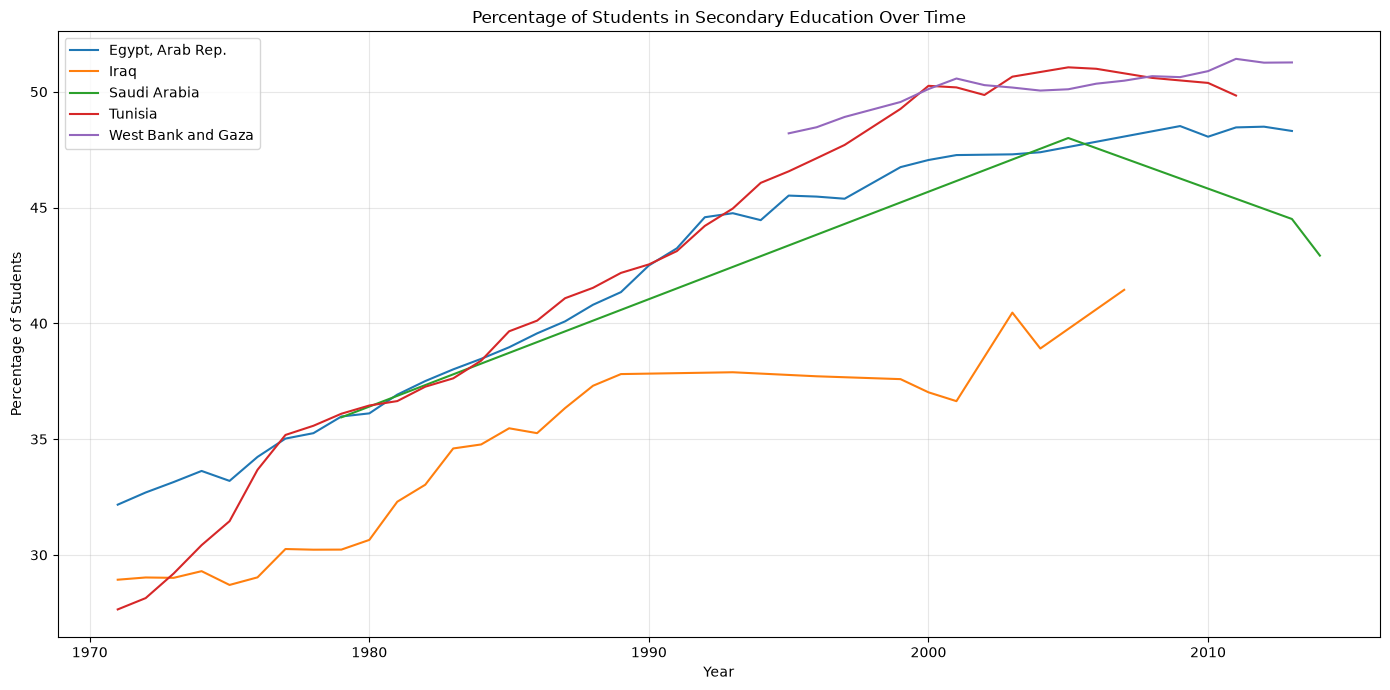

In [4]:
plt.figure(figsize=(14, 7))

for country in secondary_students['CountryName'].unique():
    country_data = secondary_students[
        secondary_students['CountryName'] == country
    ].sort_values('Year')

    plt.plot(
        country_data['Year'],
        country_data['Value'],
        label=country
    )

plt.title('Percentage of Students in Secondary Education Over Time')
plt.xlabel('Year')
plt.ylabel('Percentage of Students')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
avg_spending = education_expenditure.groupby('CountryName')['Value'].mean()
avg_spending

CountryName
Egypt, Arab Rep.    4.639459
Iraq                3.277447
Saudi Arabia        5.993614
Tunisia             6.054254
Name: Value, dtype: float64

In [8]:
avg_students = secondary_students.groupby('CountryName')['Value'].mean()
avg_students

CountryName
Egypt, Arab Rep.      41.259309
Iraq                  34.070375
Saudi Arabia          42.843660
Tunisia               41.951981
West Bank and Gaza    50.189751
Name: Value, dtype: float64

In [13]:
comparison = pd.DataFrame({
    'Avg_Education_Spending': avg_spending,
    'Avg_Secondary_Students': avg_students
})
comparison.sort_values('Avg_Education_Spending', ascending=True, inplace=True)

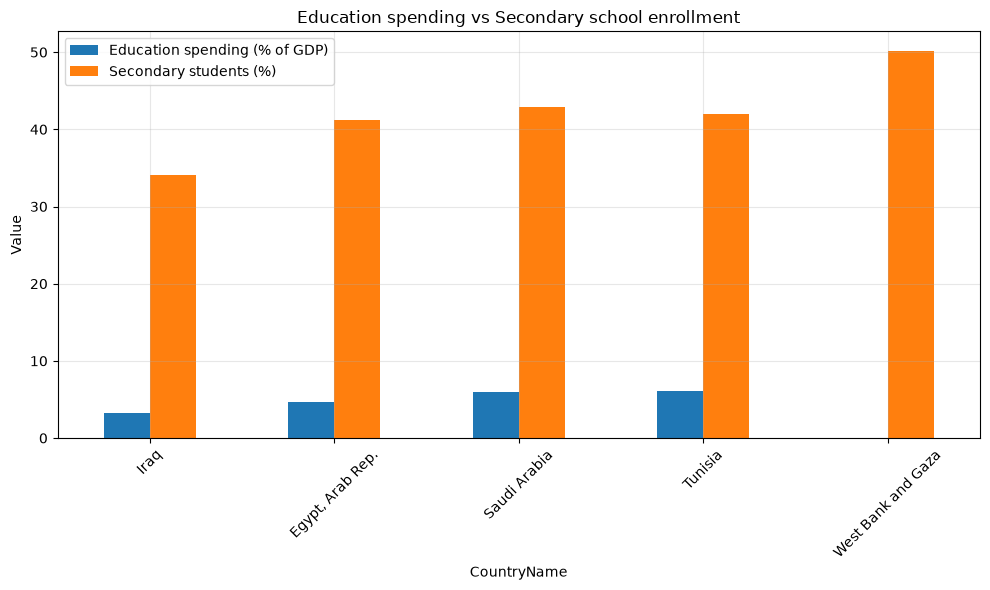

In [14]:
comparison.plot(kind='bar', figsize=(10,6))
plt.title('Education spending vs Secondary school enrollment')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.legend(['Education spending (% of GDP)', 'Secondary students (%)'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()